In [15]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import joblib

In [16]:
df = pd.read_csv(r"C:\Users\SAMIKSHA\Desktop\Factory-Reallocation-Optimization\data\ml_ready_data.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,...,Factory Latitude,Factory Longitude,Customer Latitude,Customer Longitude,Shipping Distance (km),Shipping Distance Scaled,Sales Scaled,Units Scaled,Cost Scaled,Gross Profit Scaled
0,1,US-2021-103800-CHO-MIL-31000,2024-03-01,2026-06-30,3,103800,United States,Houston,Texas,77095,...,32.076176,-81.088371,39.0997,-94.5786,1447.402305,-0.424506,-0.653283,-0.804161,-0.486444,-0.744565
1,2,US-2021-112326-CHO-TRI-54000,2024-04-01,2026-07-01,3,112326,United States,Naperville,Illinois,60540,...,32.076176,-81.088371,39.0997,-94.5786,1447.402305,-0.424506,-0.565104,-0.804161,-0.423220,-0.642208
2,3,US-2021-112326-CHO-NUT-13000,2024-04-01,2026-07-01,3,112326,United States,Naperville,Illinois,60540,...,32.881893,-111.768036,39.0997,-94.5786,1693.005751,-0.194790,-0.303210,-0.355370,-0.344191,-0.255358
3,4,US-2021-112326-CHO-SCR-58000,2024-04-01,2026-07-01,3,112326,United States,Naperville,Illinois,60540,...,32.881893,-111.768036,39.0997,-94.5786,1693.005751,-0.194790,-0.274110,-0.355370,-0.284919,-0.250843
4,5,US-2021-141817-CHO-TRI-54000,2024-05-01,2026-07-05,3,141817,United States,Philadelphia,Pennsylvania,19143,...,32.076176,-81.088371,40.7128,-74.0060,1148.912517,-0.703686,-0.234429,-0.355370,-0.166374,-0.273421


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Row ID                    10194 non-null  int64  
 1   Order ID                  10194 non-null  object 
 2   Order Date                4130 non-null   object 
 3   Ship Date                 10194 non-null  object 
 4   Ship Mode                 10194 non-null  int64  
 5   Customer ID               10194 non-null  int64  
 6   Country/Region            10194 non-null  object 
 7   City                      10194 non-null  object 
 8   State/Province            10194 non-null  object 
 9   Postal Code               10194 non-null  object 
 10  Division                  10194 non-null  int64  
 11  Region                    10194 non-null  int64  
 12  Product ID                10194 non-null  object 
 13  Product Name              10194 non-null  int64  
 14  Sales 

In [18]:
#Feature Matrix
features = [

    "Product Name",
    "Factory",
    "Ship Mode",
    "Division",
    "Region",

    "Sales Scaled",
    "Units Scaled",
    "Cost Scaled",
    "Gross Profit Scaled",

    "Shipping Distance Scaled"

]

X = df[features]

y = df["Lead Time"]

print("Feature Matrix :", X.shape)
print("Target :", y.shape)

Feature Matrix : (10194, 10)
Target : (10194,)


In [19]:
#Split Dataset
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42

)

print(X_train.shape)
print(X_test.shape)

(8155, 10)
(2039, 10)


In [21]:
#Linear Regression
lr = LinearRegression()

lr.fit(X_train,y_train)

lr_pred = lr.predict(X_test)

In [22]:
#Evaluate Linear regression
lr_rmse = np.sqrt(mean_squared_error(y_test,lr_pred))

lr_mae = mean_absolute_error(y_test,lr_pred)

lr_r2 = r2_score(y_test,lr_pred)

print("Linear Regression")

print("RMSE :",lr_rmse)

print("MAE :",lr_mae)

print("R2 :",lr_r2)

Linear Regression
RMSE : 0.4682494238589825
MAE : 0.3376178407830148
R2 : 0.9475293866176943


In [23]:
#Random Forest
rf = RandomForestRegressor(

    n_estimators=200,

    random_state=42,

    n_jobs=-1

)

rf.fit(X_train,y_train)

rf_pred = rf.predict(X_test)

In [25]:
#Evaluate Random Forest
rf_rmse = np.sqrt(mean_squared_error(y_test,rf_pred))

rf_mae = mean_absolute_error(y_test,rf_pred)

rf_r2 = r2_score(y_test,rf_pred)

print("Random Forest")

print("RMSE :",rf_rmse)

print("MAE :",rf_mae)

print("R2 :",rf_r2)

Random Forest
RMSE : 0.15297277013323765
MAE : 0.12845008846750147
R2 : 0.9943999758451464


In [26]:
#Gradient Boosting
gb = GradientBoostingRegressor(

    n_estimators=200,

    learning_rate=0.1,

    random_state=42

)

gb.fit(X_train,y_train)

gb_pred = gb.predict(X_test)

In [27]:
#Evaluate Gradient Boosting
gb_rmse = np.sqrt(mean_squared_error(y_test,gb_pred))

gb_mae = mean_absolute_error(y_test,gb_pred)

gb_r2 = r2_score(y_test,gb_pred)

print("Gradient Boosting")

print("RMSE :",gb_rmse)

print("MAE :",gb_mae)

print("R2 :",gb_r2)

Gradient Boosting
RMSE : 0.1496680255943003
MAE : 0.12817330140061983
R2 : 0.9946393223012852


In [28]:
#Compare Models
results = pd.DataFrame({

    "Model":[

        "Linear Regression",

        "Random Forest",

        "Gradient Boosting"

    ],

    "RMSE":[

        lr_rmse,

        rf_rmse,

        gb_rmse

    ],

    "MAE":[

        lr_mae,

        rf_mae,

        gb_mae

    ],

    "R2":[

        lr_r2,

        rf_r2,

        gb_r2

    ]

})

results = results.sort_values("RMSE")

results

,Model,RMSE,MAE,R2
2,Gradient Boosting,0.149668,0.128173,0.994639
1,Random Forest,0.152973,0.128450,0.994400
0,Linear Regression,0.468249,0.337618,0.947529


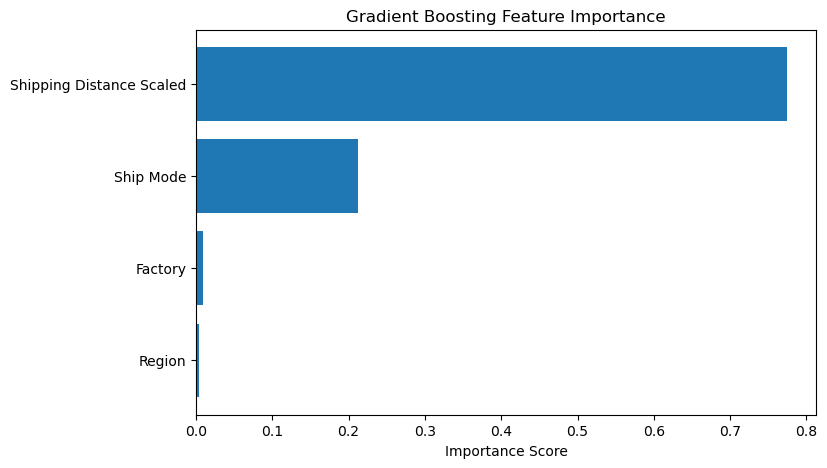

In [31]:
#Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": gb.feature_importances_
})

# Keep only meaningful features
importance = importance[importance["Importance"] > 0.001]

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance Score")
plt.title("Gradient Boosting Feature Importance")

plt.show()

In [34]:
#Save Best Model
joblib.dump(

    gb,

    "gradient_boosting.pkl"

)

['gradient_boosting.pkl']

In [35]:
#Save Model Comparison
results.to_csv(

    "model_results.csv",

    index=False

)